# Trabajo Práctico 1

In [5]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from PIL import Image

## Funciones Auxiliares

In [ ]:
def get_model():  # Función para recibir un modelo de regresion logaritmica
    # newton-cg converge en todos los k (lbfgs no converge con algunos k)
    lr_model = LogisticRegression(max_iter=5000, solver="newton-cg")
    return lr_model


def train(X_train, y_train, lr_model):  # Función para entrenar
    # Entrenamiento del modelo
    lr_model.fit(X_train, y_train)


def test(X_test, y_test, lr_model):  # Función para testear
    y_pred = lr_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc


def get_train_data(  # Data para entrenamiento con parametros por default
    ruta_train="./dataset_tp1/train/", ruta_train_labels="dataset_tp1/train_labels.csv"
):
    """
    - Carga las imágenes .png, las aplana y arma la matriz X_train.
    - Devuelve X_train de forma (n_train, 16384) y y_train de forma (n_train) con valores en {0, 1} (0 = sano, 1 = neumonía)
    """
    X_train = []
    for archivo in sorted(os.listdir(ruta_train)):
        if archivo.endswith(".png"):
            ruta_imagen = ruta_train + archivo
            imagen = Image.open(ruta_imagen)
            imagen_array = np.array(imagen).flatten()
            X_train.append(imagen_array)

    X_train = np.array(X_train)

    train_labels = pd.read_csv(ruta_train_labels)
    y_train = train_labels["clase"].to_numpy()

    return X_train, y_train


def get_test_data(  # Data para tests con parámetros por default
    ruta_test="./dataset_tp1/test/", ruta_test_labels="dataset_tp1/test_labels.csv"
):
    """
    - Carga las imágenes .png de test, las aplana y arma la matriz X_test.
    - Devuelve X_test de forma (n_test, 16384) y y_test de forma (n_test) con valores en {0, 1} (0 = sano, 1 = neumonía).
    - NO se usa para ajustar ningún parámetro del modelo ni de PCA (mu, V):
    solo se proyecta y se evalúa con lo aprendido en train.
    """
    X_test = []
    for archivo in sorted(os.listdir(ruta_test)):
        if archivo.endswith(".png"):
            ruta_imagen = ruta_test + archivo
            imagen = Image.open(ruta_imagen)
            imagen_array = np.array(imagen).flatten()
            X_test.append(imagen_array)
    X_test = np.array(X_test)

    test_labels = pd.read_csv(ruta_test_labels)
    y_test = test_labels["clase"].to_numpy()
    return X_test, y_test


def USV(X):  # PCA: centra datos y obtiene componentes principales
    """
    - Centra los datos restando la media (ux).
    - Se calcula PCA usando SVD de la matriz centrada Xc, en vez de diagonalizar 
    la matriz de covarianza (m x m = 16384 x 16384), porque esa diagonalización
    sería computacionalmente inviable dado que m >> n.
    - U: (n, r), S: (r, r) diagonal con los valores singulares,
    - V: (m, r) cuyas columnas son las direcciones principales (autovectores
    de la covarianza), con r = min(n, m).
    """
    ux = X.mean(axis=0)
    Xc = X - ux

    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    V = Vt.T
    S = np.diag(s)

    return U, S, V, ux


def proyectar_k(X, mu, V, k):  # proyecta sobre las k primeras direcciones principales
    """
    - Proyecta X sobre las k primeras direcciones principales, que son las columnas de V.
    - mu y V deben provenir siempre del conjunto de ENTRENAMIENTO, incluso
    si X es el conjunto de test, para no filtrar información de test en la estimación de la base de proyección.
    """
    Xc = X - mu
    Vk = V[:, :k]

    return Xc @ Vk


def scatter1b(X_test, y_test):  # visualiza la proyección en 2 componentes
    sanos = []
    enfermos = []
    for i in range(len(X_test)):
        if y_test[i] == 0:
            sanos.append(X_test[i])
        else:
            enfermos.append(X_test[i])

    sanos = np.array(sanos)
    enfermos = np.array(enfermos)

    plt.scatter(sanos[:, 0], sanos[:, 1], c="blue", label="Pulmones sanos")
    plt.scatter(enfermos[:, 0], enfermos[:, 1], c="red", label="Pulmones enfermos")
    plt.ylabel("Componente 2")
    plt.xlabel("Componente 1")
    plt.title("Análisis de 2 componentes principales")
    plt.legend()
    plt.show()

### Reporte de metodología

Cada imagen del dataset PneumoniaMNIST es una radiografía de pulmonese en blanco y negro de 128×128 píxeles. Para poder utilizarla como entrada de un clasificador 
lineal, se aplana a un vector de dimensión $m = 128 \times 128 = 16384$, de modo 
que cada píxel pasa a ser un punto en $\mathbb{R}^{16384}$. El conjunto de 
entrenamiento y el de test quedan representados entonces como matrices 
$X_{\text{train}} \in \mathbb{R}^{n_{\text{train}} \times m}$ y 
$X_{\text{test}} \in \mathbb{R}^{n_{\text{test}} \times m}$, con sus etiquetas 
asociadas (0 = sano, 1 = neumonía) tomadas de los archivos CSV correspondientes.

La métrica de evaluación utilizada es el accuracy, es decir, la proporción de 
predicciones correctas sobre el total de observaciones del conjunto de prueba.

La idea de aplicar PCA en este problema es reducir la dimensionalidad de las 
imágenes conservando la mayor parte de la variabilidad de los datos, proyectando cada 
observación sobre las direcciones principales obtenidas a partir del 
conjunto de entrenamiento.

## Ejercicio 1

Accuracy antes de aplicar PCA: 0.8034188034188035


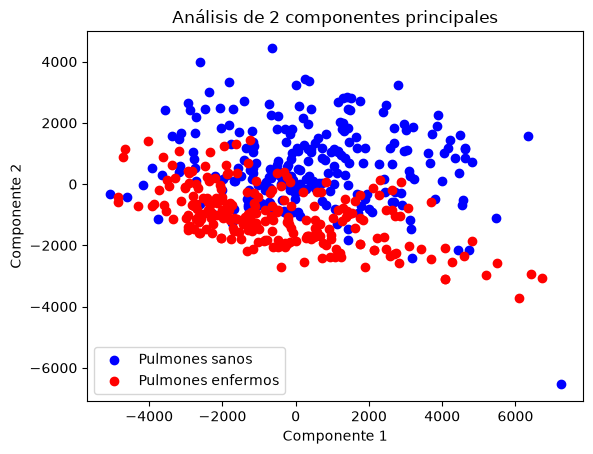

Mejor accuracy: 0.8504273504273504 con k = 12


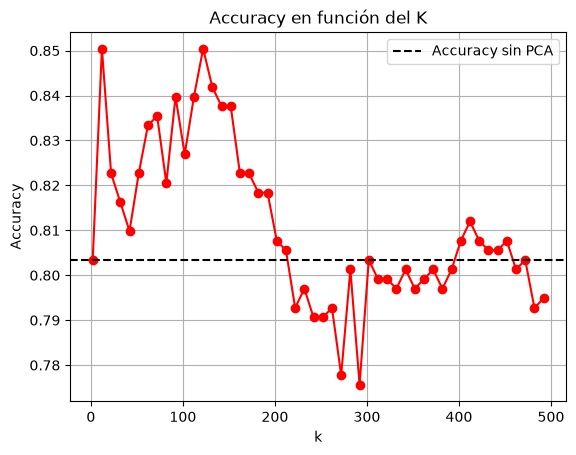

In [7]:
X_train, y_train = get_train_data()
X_test, y_test = get_test_data()

# 1.a)-------------SIN PCA-------------------------------------
# baseline del modelo sin reducción de dimensionalidad

lr_model = get_model()
train(X_train, y_train, lr_model)
accuracy_base = test(X_test, y_test, lr_model)
print(f"Accuracy antes de aplicar PCA: {accuracy_base}")


# 1.b)----------PROYECCIONES + SCATTER-------------------------
# proyecta los datos en 2 dimensiones para visualizar separación

U, S, V, ux = USV(X_train)  # Recibimos U, S, V, ux
X_test_K2 = proyectar_k(
    X_test, ux, V, 2
)  # Proyectamos el conjunto de test sobre la matriz de proyeccion
scatter1b(X_test_K2, y_test)


# 1.c)----------CON PCA + DISTINTOS K--------------
# compara accuracy para distintos niveles de reducción
valores_k = []
accuracies_por_k = []

for k in range(2, 500, 10):
    valores_k.append(k)
    lr_model_k = get_model()
    X_train_k = proyectar_k(X_train, ux, V, k)
    X_test_k = proyectar_k(X_test, ux, V, k)
    train(X_train_k, y_train, lr_model_k)
    accuracy_k = test(X_test_k, y_test, lr_model_k)
    accuracies_por_k.append(accuracy_k)

valores_k = np.array(valores_k)
accuracies_por_k = np.array(accuracies_por_k)

# mejor k según accuracy en test
idx_mejor = np.argmax(accuracies_por_k)
mejor_k = valores_k[idx_mejor]
mejor_accuracy = accuracies_por_k[idx_mejor]
print(f"Mejor accuracy: {mejor_accuracy} con k = {mejor_k}")

plt.plot(valores_k, accuracies_por_k, "ro-")
plt.title("Accuracy en función del K")
plt.axhline(accuracy_base, c="black", linestyle="--", label="Accuracy sin PCA")
plt.ylabel("Accuracy")
plt.xlabel("k")
plt.legend()
plt.grid()
plt.show()

### Reporte del Ejercicio 1

El accuracy obtenido al entrenar el clasificador sobre las imágenes completas es el *baseline* Este valor permite 
cuantificar, en los puntos siguientes, cuánto se pierde (o si eventualmente 
se gana) al proyectar los datos sobre un subespacio de menor dimensión.

La proyección del conjunto de test sobre las dos primeras componentes 
principales, junto con el scatter coloreado por clase (sano/neumonía), 
permite visualizar a simple vista si las direcciones de mayor varianza del 
conjunto de entrenamiento sirven para separar un pulmon enfermo de uno sano.

Para estudiar cómo evoluciona el desempeño con la cantidad de componentes 
retenidas, se evalúa el accuracy del modelo PCA+LR para valores de $k$ que 
van desde una reducción muy agresiva ($k=2$) hasta una fracción considerable 
de la dimensión original, en pasos regulares.

La conclusión que se busca extraer de este análisis es de tipo cualitativo: 
identificar si existe un valor de $k$ a partir del cual el accuracy es igual o mejor que en baseline (lo que indicaría que las 
componentes principales adicionales aportan información nula o incluso llegan a confundir al modelo), o si, por el contrario, el desempeño sigue mejorando 
con $k$ creciente.

## Ejercicio 2

Scatter con p= 0.1


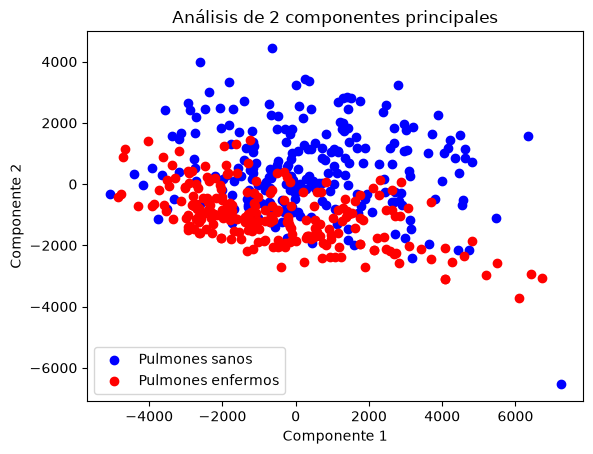

Scatter con p= 0.2


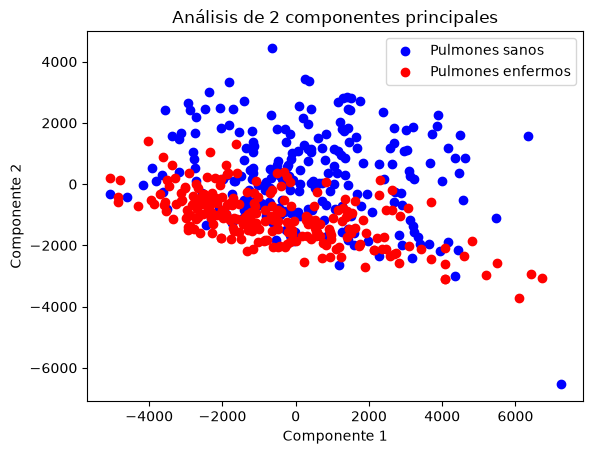

Scatter con p= 0.3


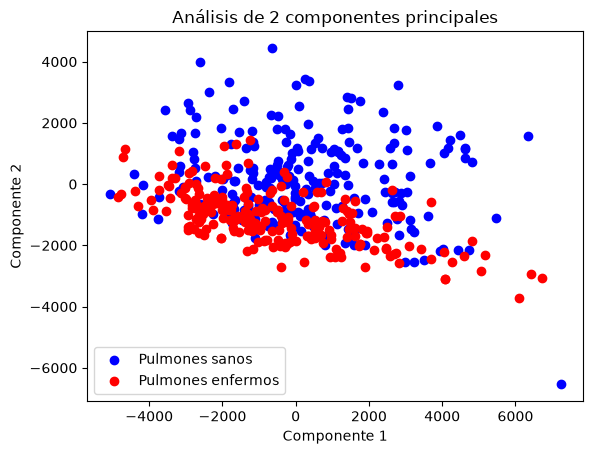

Scatter con p= 0.4


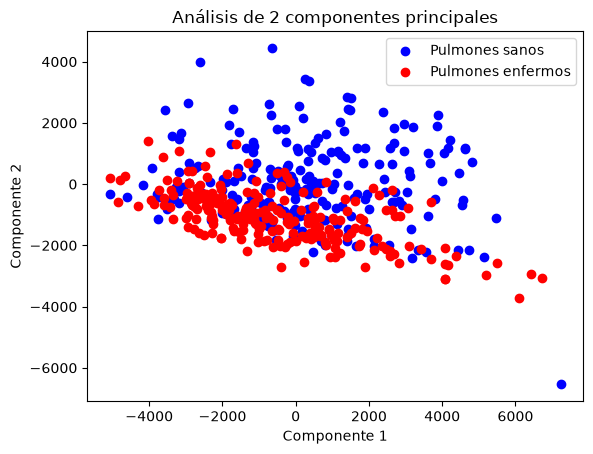

Scatter con p= 0.5


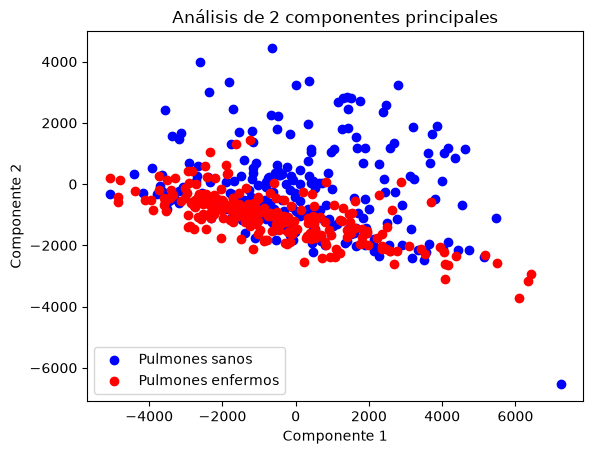

Scatter con p= 0.6


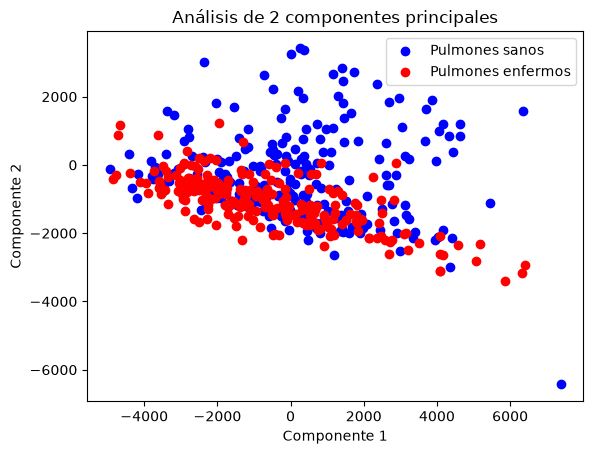

Scatter con p= 0.7


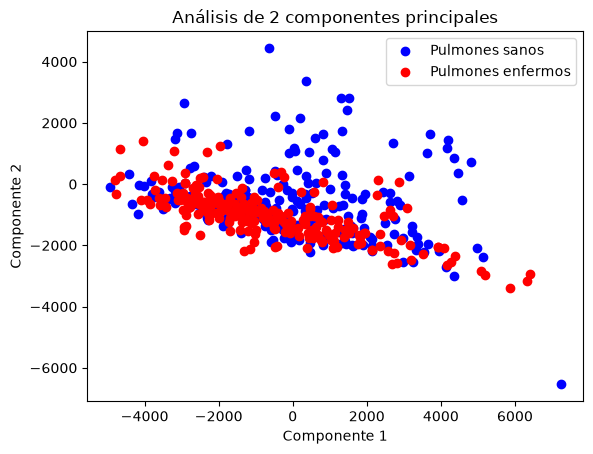

Scatter con p= 0.8


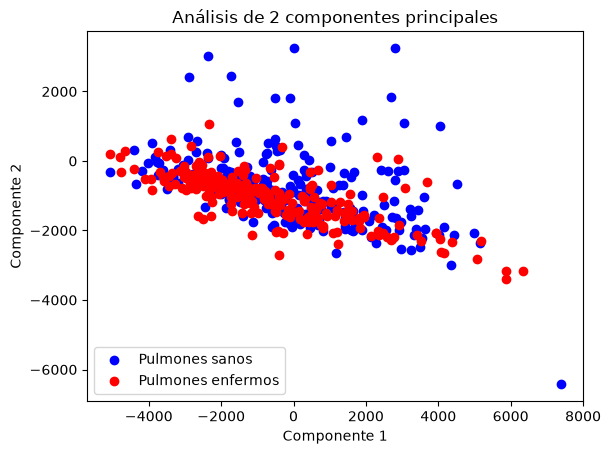

Scatter con p= 0.9


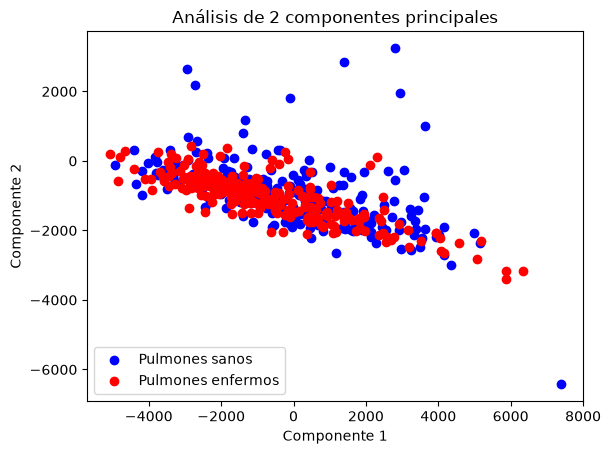

In [8]:
"""
Reutilizo variables del punto 1
X_train, y_train, X_test, y_test
ux: Media
V: Matriz de componentes principales
"""

X_train_K2 = proyectar_k(X_train, ux, V, 2)
X_test_K2 = proyectar_k(X_test, ux, V, 2)

lr_model_MC = get_model()
train(X_train_K2, y_train, lr_model_MC)

A0 = test(X_test_K2, y_test, lr_model_MC)

# cada imagen puede rotarse con probabilidad p para evaluar robustez


def perturbaciones(X_test, p):
    X_test_perturbado = X_test.copy()
    for i in range(len(X_test_perturbado)):
        if np.random.rand() < p:
            img = X_test_perturbado[i].reshape(128, 128)
            img_rotada = np.rot90(img, 2)
            X_test_perturbado[i] = img_rotada.flatten()
    return X_test_perturbado


N_mc = 1000
tolerancia = 0.1

accuracies_promedio = []
prob_perdida_supera_tolerancia = []
accuracies_por_p = {}
probabilidades_MC = {}

p_values = np.arange(0.1, 1.0, 0.1)
for proba in p_values:
    proba = round(proba, 1)

    accuracies_mc = []
    indicadores = []

    for i in range(N_mc):
        X_test_mod = perturbaciones(X_test, proba)
        X_test_K2_mod = proyectar_k(X_test_mod, ux, V, 2)

        accuracy_local = test(X_test_K2_mod, y_test, lr_model_MC)
        accuracies_mc.append(accuracy_local)

        perdida_i = A0 - accuracy_local
        indicador_i = 1 if perdida_i > tolerancia else 0
        indicadores.append(indicador_i)
        # solo un scatter por valor de p para visualizar la variación
        # a - Scatter solo una vez por cada proba distinta
        if i == 0:
            print(f"Scatter con p= {proba}")
            scatter1b(X_test_K2_mod, y_test)
    # promedio de la accuracy bajo perturbación
    # b - Metodo Montecarlo - Valor medio
    accuracies_mc = np.array(accuracies_mc)
    accuracy_promedio = np.mean(accuracies_mc)
    # probabilidad estimada de perder más que la tolerancia
    # c - Proba de superar tolerancia
    perdidas = A0 - accuracies_mc
    prob_perdida = np.mean(perdidas > tolerancia)

    accuracies_promedio.append(accuracy_promedio)
    prob_perdida_supera_tolerancia.append(prob_perdida)
    accuracies_por_p[proba] = accuracies_mc

    # 3 - promedio de las funciones indicadoras
    probabilidad_estimada = np.mean(indicadores)
    probabilidades_MC[proba] = probabilidad_estimada

### Reporte del Ejercicio 2
En esta celda debe explicarse:
- cómo se construye la perturbación sobre las imágenes,
- qué significa la probabilidad p de rotación,
- cuál es el modelo base que se usa para evaluar la robustez,
- y qué representa la pérdida L(p) y la tolerancia elegida.

No se debe poner el resultado final; solo debe quedar claro qué se está simulando y qué se pretende medir con la variación de p.

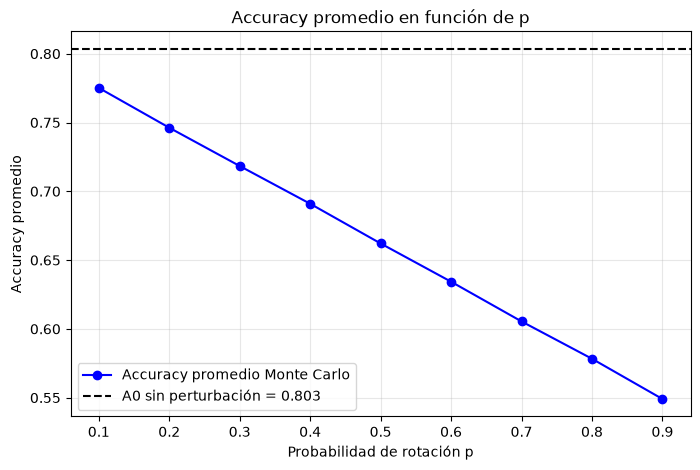

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(
    p_values,
    accuracies_promedio,
    "o-",
    color="blue",
    label="Accuracy promedio Monte Carlo",
)
plt.axhline(A0, linestyle="--", color="black", label=f"A0 sin perturbación = {A0:.3f}")
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Accuracy promedio")
plt.title("Accuracy promedio en función de p")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Reporte del gráfico de accuracies promedio
En esta celda debe describirse:
- qué representa el eje horizontal y el eje vertical,
- qué se compara en la curva de accuracy promedio frente a p,
- cómo se interpreta la línea horizontal con el valor base A0,
- y qué patrón esperado debe reportarse sobre la degradación del rendimiento a medida que aumenta la probabilidad de perturbación.

Aquí solo debe quedar claro qué información grafica el análisis y qué tendencia se debe comentar, sin incluir el valor final ni la conclusión definitiva.

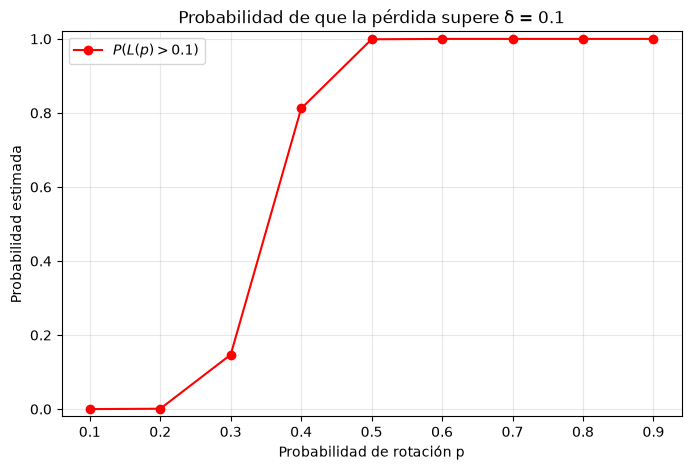

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(
    p_values,
    prob_perdida_supera_tolerancia,
    "o-",
    color="red",
    label=r"$P(L(p) > 0.1)$",
)
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Probabilidad estimada")
plt.title("Probabilidad de que la pérdida supere δ = 0.1")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Reporte del gráfico de probabilidad de pérdida
En esta celda debe explicarse:
- qué representa la probabilidad estimada P(L(p) > 0.1),
- cómo se interpreta la curva en función de p,
- qué relación tiene esta gráfica con la robustez del clasificador frente a perturbaciones,
- y qué tipo de conclusión se espera reportar acerca del comportamiento del sistema bajo mayor rotación.

No se deben escribir resultados finales ni afirmaciones concluyentes; solo debe quedar indicado qué debe analizarse en ese gráfico.

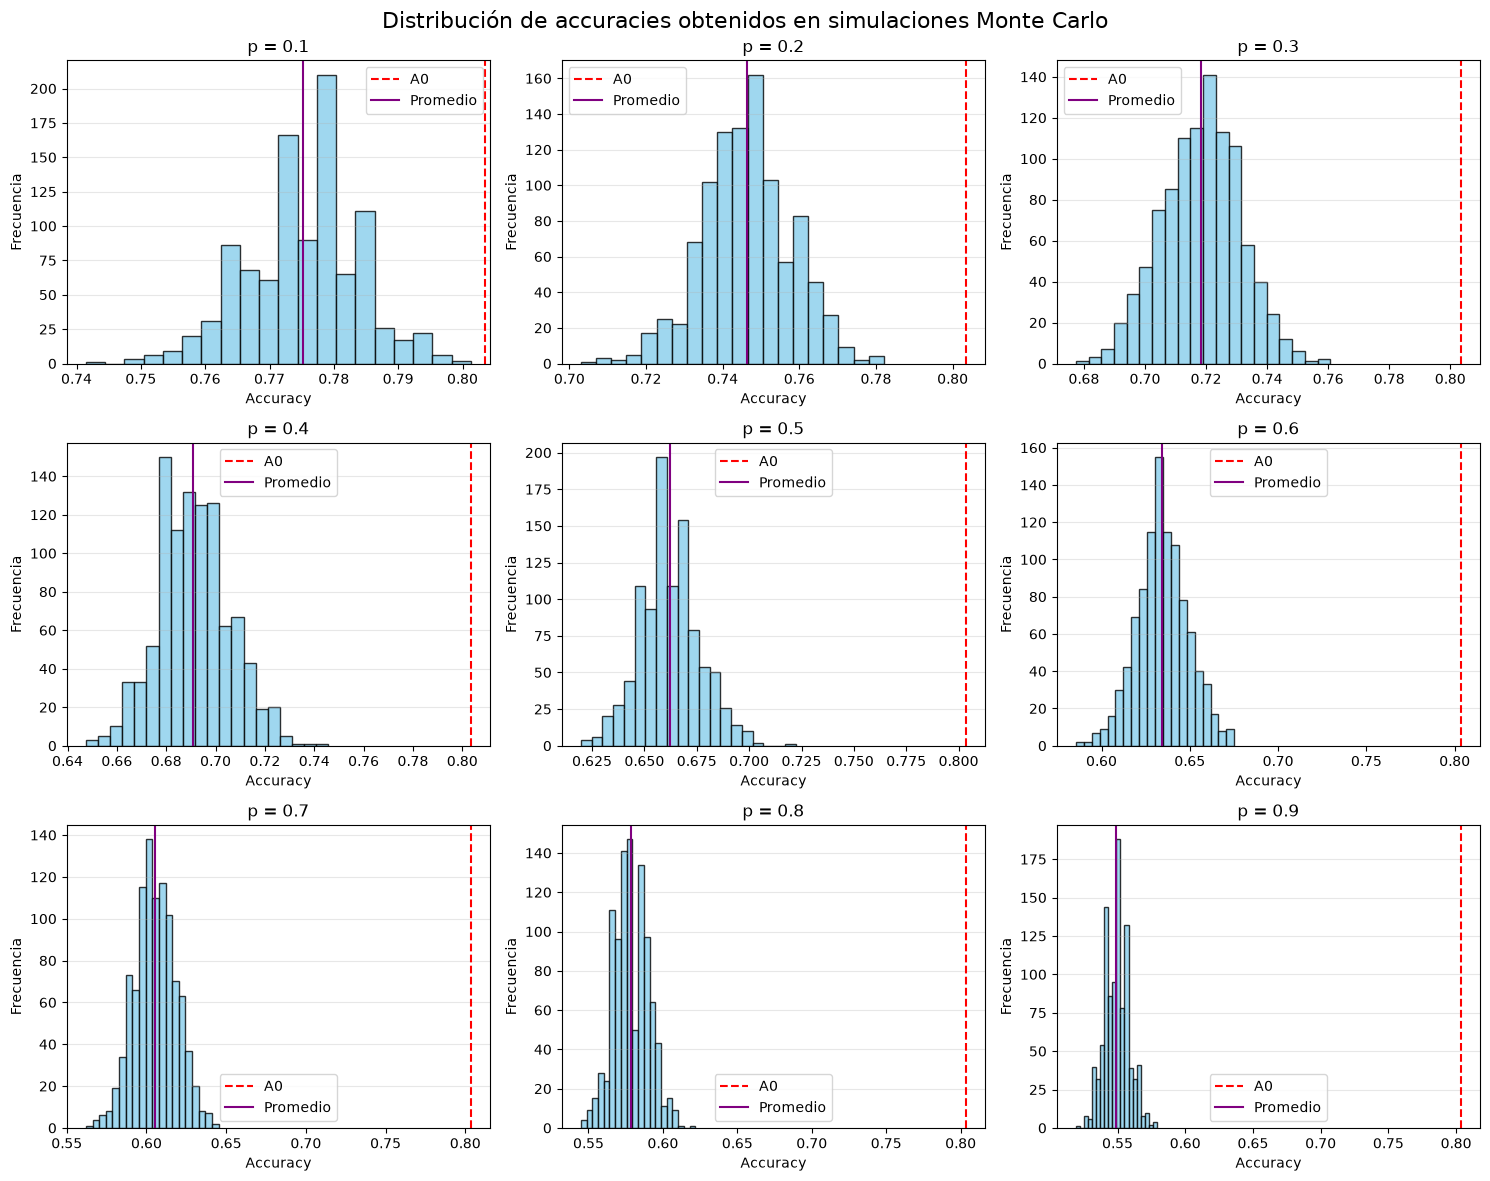

In [11]:
# 2(d) Histogramas de todos los valores de p en una misma figura

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# cada histograma resume la distribución para un nivel distinto de perturbación
for ax, (proba, acc_mc) in zip(axes, accuracies_por_p.items()):
    ax.hist(acc_mc, bins=20, color="skyblue", edgecolor="black", alpha=0.8)

    ax.axvline(A0, color="red", linestyle="--", linewidth=1.5, label="A0")

    ax.axvline(
        np.mean(acc_mc), color="purple", linestyle="-", linewidth=1.5, label="Promedio"
    )

    ax.set_title(f"p = {proba}")
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.suptitle(
    "Distribución de accuracies obtenidos en simulaciones Monte Carlo", fontsize=16
)

plt.tight_layout()
plt.show()

### Reporte de histogramas
En esta celda debe indicarse:
- qué muestra cada histograma según el valor de p,
- cómo se interpreta la posición relativa del promedio y del valor base A0,
- qué información aporta la comparación entre distribuciones para distintos niveles de perturbación,
- y qué aspecto de robustez o sensibilidad se debe reportar para cada p.

La idea es dejar claro qué hay que analizar en cada subplot, sin escribir resultados ni conclusiones aún.

### Reporte final del ejercicio 2
En esta celda debe resumirse:
- qué estimación Monte Carlo se está reportando,
- cuál es la interpretación de la probabilidad estimada para cada valor de p,
- qué relación tiene ese resultado con la tolerancia elegida,
- y cómo se debe presentar la conclusión general sobre la robustez del modelo frente a las perturbaciones.

La celda no debe contener resultados definitivos ni la explicación final del análisis; solo debe dejar en claro qué información debe resumirse al cierre del ejercicio.

## Ejercicio 3 — Justificación mediante la Ley de los Grandes Números

Para cada valor fijo de la probabilidad de perturbación $p$, realizamos
$N_{MC}$ simulaciones independientes. En la simulación $i$, se obtiene un
accuracy $A_p^{(i)}$ y, por lo tanto, una pérdida:

$$
L_i(p) = A_0 - A_p^{(i)}
$$

donde $A_0$ es el accuracy del clasificador sin perturbaciones y
$A_p^{(i)}$ es el accuracy obtenido en la realización $i$ al rotar cada
imagen de test con probabilidad $p$.

Definimos la variable aleatoria indicadora del evento de interés:


$$
I_i =
\begin{cases}
1, & \text{si } L_i(p) > \delta, \\
0, & \text{si } L_i(p) \leq \delta.
\end{cases}
$$

La esperanza de una variable indicadora es igual a la probabilidad del
evento que indica. Por lo tanto:

$$
\mathbb{E}[I_i]
=
\mathbb{E}\left[\mathbb{1}\{L_i(p) > \delta\}\right]
=
P_p\bigl(L(p) > \delta\bigr)
$$

Para un valor fijo de $p$, las simulaciones se generan de manera
independiente y con la misma distribución. En consecuencia,
$I_1, I_2, \ldots, I_{N_{MC}}$ son variables aleatorias independientes e
idénticamente distribuidas, cuyos valores posibles son $0$ y $1$.

Por la Ley de los Grandes Números, al aumentar el número de simulaciones,
el promedio muestral converge a la esperanza:

$$
\frac{1}{N_{MC}}
\sum_{i=1}^{N_{MC}} I_i
\xrightarrow[N_{MC} \to \infty]{}
\mathbb{E}[I_i]
$$

Reemplazando la definición de $I_i$, se obtiene el estimador de la
probabilidad solicitada:

$$
\widehat{P}_p\bigl(L(p) > \delta\bigr)
=
\frac{1}{N_{MC}}
\sum_{i=1}^{N_{MC}}
\mathbb{1}\{L_i(p) > \delta\}
$$

Por lo tanto, este promedio estima la proporción de simulaciones para las
cuales la pérdida de accuracy supera la tolerancia $\delta$. A medida que
$N_{MC}$ aumenta, el estimador se aproxima a la probabilidad verdadera
$P_p\bigl(L(p) > \delta\bigr)$.

En la implementación, la expresión `L_p > tolerancia` genera una
variable indicadora para cada simulación: vale `True` si la pérdida supera
el umbral y `False` en caso contrario. Al calcular
`np.mean(L_p > tolerancia)`, NumPy promedia estos valores, interpretando
`True` como 1 y `False` como 0. De este modo, el resultado representa la
proporción de simulaciones en las que ocurre el evento
$L_i(p) > \delta$, que es precisamente el estimador Monte Carlo
justificado anteriormente.

In [12]:
print("Estimación Monte Carlo de P(L(p) > δ)")
print(f"Tolerancia δ = {tolerancia}")
print(f"Cantidad de simulaciones N_mc = {N_mc}\n")

for proba, probabilidad_estimada in probabilidades_MC.items():
    print(
        f"p = {proba:.1f} | "
        f"P_hat(L(p) > {tolerancia}) = {probabilidad_estimada:.4f}"
    )

Estimación Monte Carlo de P(L(p) > δ)
Tolerancia δ = 0.1
Cantidad de simulaciones N_mc = 1000

p = 0.1 | P_hat(L(p) > 0.1) = 0.0000
p = 0.2 | P_hat(L(p) > 0.1) = 0.0010
p = 0.3 | P_hat(L(p) > 0.1) = 0.1470
p = 0.4 | P_hat(L(p) > 0.1) = 0.8120
p = 0.5 | P_hat(L(p) > 0.1) = 0.9990
p = 0.6 | P_hat(L(p) > 0.1) = 1.0000
p = 0.7 | P_hat(L(p) > 0.1) = 1.0000
p = 0.8 | P_hat(L(p) > 0.1) = 1.0000
p = 0.9 | P_hat(L(p) > 0.1) = 1.0000
